<h1 style="background-color:blue; color: white; padding: 15px; text-align: Center">The Energy Price of Planning: Energy–Performance Trade-offs in
LLM-Based Software Engineering Agents.</h1>


### Energy-Performance Trade-offs in LLM-Based Software Engineering Agents

This notebook reproduces **every number, table, statistical test, and figure** in the
paper directly from the raw results file `run_table.csv`. It is self-contained: run the
cells top to bottom and you will regenerate Table 1, the hypothesis tests for H1–H3, the
Pareto analysis, the Memory–4B reliability reversal, and Figures 3–5.

**Contents**
1. Setup and dependencies
2. Load and clean the raw data
3. The two evaluation bases (reliability-aware vs. valid-inference)
4. Table 1 — per-configuration descriptives (reliability-aware)
5. Marginal means (by pattern, by model)
6. Hypothesis tests (H1–H3): ANOVA + partial η², Kruskal–Wallis, logistic LR tests
7. Pareto front (RQ4)
8. The Memory–4B reliability reversal
9. Figures 3, 4, 5 (publication code)
10. Summary of reproduced headline numbers

> **Accounting note.** Unless stated otherwise, all metrics use the **reliability-aware
> basis**: the denominator is *every attempted run*, including runs that consumed energy
> but produced no usable output. Section 3 shows the contrast with the *valid-inference*
> basis (runs that reached the model), which is the core of the reliability finding.

<h3 style="background-color:blue; color: white; padding: 15px;"> 1. Setup and dependencies</h3>

Standard scientific-Python stack plus `statsmodels` for the ANOVA / logistic models.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

CSV = "run_table.csv"          # path to the raw results
KWH_TO_KJ = 3600.0             # 1 kWh = 3600 kJ
KWH_TO_J  = 3.6e6              # 1 kWh = 3.6e6 J
print("pandas", pd.__version__, "| statsmodels", sm.__version__)

pandas 3.0.3 | statsmodels 0.14.6


<h3 style="background-color:blue; color: white; padding: 15px;"> 2. Load and clean the raw data </h3>

Each row of `run_table.csv` is one **run** = (planning pattern × model × task). Cleaning steps:

- **Drop setup failures.** Two rows have status `FAILED_MODEL_VERIFY` (the model failed to
  load/verify before any task work). These are infrastructure failures, not experimental
  outcomes, so we drop them, leaving **1,500 runs** (5 patterns × 3 models × ~100 tasks).
- **Rename `rag` → `memory`.** The memory pattern is implemented as retrieval-augmented
  generation over past tasks; the code logs it as `rag`, the paper calls it `memory`.
- **Energy units.** Energy is logged in kWh; we add kJ (paper tables) and J columns.
- **Success.** `pass_rate ∈ {0,1}` is the per-task success flag (it equals 1 only for
  `COMPLETED` runs whose tests passed), so `success = pass_rate`.
- **No-output flag.** A run produced *no usable output* if it made no model calls **and**
  generated no tokens — i.e. it consumed wall-clock time/energy (typically a timeout
  against the 15-minute cap) without ever reaching usable inference.

In [2]:
df = pd.read_csv(CSV)
print("raw rows:", len(df), "| statuses:", df.status.value_counts().to_dict())

# drop infrastructure (model-verify) failures
df = df[~df.status.str.lower().eq("failed_model_verify")].copy()

# canonical labels
df["model"]   = df.model.str.lower()
df["pattern"] = df.pattern.str.lower().replace({"rag": "memory"})

# derived columns
df["total_tokens"] = df.prompt_tokens + df.completion_tokens
df["E_kJ"] = df.energy_kwh * KWH_TO_KJ
df["E_J"]  = df.energy_kwh * KWH_TO_J
df["success"]  = df.pass_rate.astype(int)
df["no_output"] = ((df.llm_calls <= 0) & (df.total_tokens <= 0)).astype(int)

print("cleaned rows:", len(df))
print("patterns:", sorted(df.pattern.unique()))
print("models  :", sorted(df.model.unique()))
print("unique tasks:", df.task_name.nunique())
df.head(3)

raw rows: 1502 | statuses: {'FAILED': 874, 'COMPLETED': 626, 'FAILED_MODEL_VERIFY': 2}
cleaned rows: 1500
patterns: ['baseline', 'decomposition', 'memory', 'multiplan', 'reflection']
models  : ['qwen3:14b', 'qwen3:4b', 'qwen3:8b']
unique tasks: 100


,run_id,experiment_id,pattern,model,task_name,status,llm_calls,prompt_tokens,completion_tokens,planner_calls,executor_calls,duration_seconds,energy_kwh,pass_rate,timestamp,total_tokens,E_kJ,E_J,success,no_output
0,20260508-120747--baseline--qwen3_4b,20260508-120747--experiment,baseline,qwen3:4b,accumulate,COMPLETED,1,870,1171,0,1,19.889690,0.000300,1,2026-05-09T01:02:57Z,2041,1.079932,1079.9316,1,0
1,20260508-120747--baseline--qwen3_4b,20260508-120747--experiment,baseline,qwen3:4b,acronym,FAILED,2,3089,12006,0,2,187.482696,0.002169,0,2026-05-09T01:02:57Z,15095,7.809941,7809.9408,0,0
2,20260508-120747--baseline--qwen3_4b,20260508-120747--experiment,baseline,qwen3:4b,affine-cipher,FAILED,0,0,0,0,0,900.000000,0.013116,0,2026-05-09T01:02:57Z,0,47.216084,47216.0844,0,1


Canonical orderings, labels, and a colour-blind-safe (Okabe–Ito) palette, reused by every table and figure below.

In [3]:
PATTERN_ORDER = ["baseline", "memory", "decomposition", "reflection", "multiplan"]
MODEL_ORDER   = ["qwen3:4b", "qwen3:8b", "qwen3:14b"]
PATTERN_LABEL = {"baseline":"Baseline","memory":"Memory","decomposition":"Decomposition",
                 "reflection":"Reflection","multiplan":"Multi-plan"}
MODEL_LABEL   = {"qwen3:4b":"4B","qwen3:8b":"8B","qwen3:14b":"14B"}

# Okabe-Ito palette
PATTERN_COLOR = {"baseline":"#0072B2","memory":"#E69F00","decomposition":"#009E73",
                 "reflection":"#D55E00","multiplan":"#CC79A7"}
MODEL_COLOR   = {"qwen3:4b":"#56B4E9","qwen3:8b":"#E69F00","qwen3:14b":"#009E73"}
MODEL_MARKER  = {"qwen3:4b":"o","qwen3:8b":"*","qwen3:14b":"^"}

<h3 style="background-color:blue; color: white; padding: 15px;"> The two evaluation bases </h3>

The paper's central methodological point is that **the denominator changes the conclusion.**
We define two views of the data:

| Basis | Rows kept | Used for |
|---|---|---|
| **Reliability-aware** (`df`) | *all* attempted runs (1,500) | primary analysis, Table 1, all tests |
| **Valid-inference** (`df_valid`) | only runs that reached the model | contrast that exposes the reliability illusion |

A run is *valid-inference* if it made at least one model call **or** produced tokens.

In [4]:
df_valid = df[~df.no_output.astype(bool)].copy()
print(f"reliability-aware (all):   {len(df):4d} runs")
print(f"valid-inference (reached): {len(df_valid):4d} runs")
print(f"no-output (energy, no result): {df.no_output.sum():4d} runs "
      f"({100*df.no_output.mean():.1f}%)")

reliability-aware (all):   1500 runs
valid-inference (reached): 1294 runs
no-output (energy, no result):  206 runs (13.7%)


<h3 style="background-color:blue; color: white; padding: 15px;"> 4. Table 1 — per-configuration descriptives (reliability-aware) </h3>

For each of the 15 configurations we report, over **all attempted runs**:

- **Succ. (%)** — successes / all attempts
- **No-out (%)** — share of runs that produced no usable output
- **Energy (kJ)** — mean energy per run
- **Energy/succ. (kJ)** — total energy over all runs ÷ number of successes  *(paper Eq. 1)*
- **Runtime (s)**, **Tokens**, **Calls** — mean per run

$$E^{\text{succ}}_{c} = \frac{\sum_{r \in c} e_r}{\sum_{r \in c} s_r}$$

In [5]:
def per_config_table(data):
    g = data.groupby(["pattern", "model"], observed=True)
    t = pd.DataFrame({
        "n":      g.size(),
        "Succ%":  g.success.mean() * 100,
        "NoOut%": g.no_output.mean() * 100,
        "Energy_kJ":  g.E_kJ.mean(),
        "EperSucc_kJ": g.E_kJ.sum() / g.success.sum(),
        "Runtime_s":  g.duration_seconds.mean(),
        "Tokens":     g.total_tokens.mean(),
        "Calls":      g.llm_calls.mean(),
    })
    idx = pd.MultiIndex.from_product([PATTERN_ORDER, MODEL_ORDER], names=["pattern","model"])
    return t.reindex(idx)

table1 = per_config_table(df)
table1.round(1)

n  Succ%  NoOut%  Energy_kJ  EperSucc_kJ  Runtime_s   Tokens  Calls
pattern       model                                                                           
baseline      qwen3:4b   100   51.0    24.0       21.9         43.0      412.1   5847.8    1.0
              qwen3:8b   100   58.0    25.0       17.6         30.4      343.0   4185.3    1.0
              qwen3:14b  100   50.0     0.0       16.9         33.8      494.5   4889.7    1.5
memory        qwen3:4b   100   13.0    87.0       41.8        321.5      800.2    385.4    0.1
              qwen3:8b   100   52.0    27.0       20.4         39.3      397.1   4667.1    1.0
              qwen3:14b  100   45.0     9.0       24.5         54.5      561.6   5809.2    1.5
decomposition qwen3:4b   100   28.0     0.0       20.3         72.5      425.3  25473.4    6.0
              qwen3:8b   100   28.0     0.0       26.3         94.1      463.6  13379.0    4.9
              qwen3:14b  100   21.0     0.0       18.2         86.8      746.1   8495.2    5.2
reflection    qwen3:4b   100   51.0    16.0       44.1         86.4      476.3  15737.6    2.6
              qwen3:8b   100   53.0    18.0       43.3         81.7      468.8  13668.7    2.6
              qwen3:14b  100   43.0     0.0       56.6        131.5      668.3  13063.4    3.4
multiplan     qwen3:4b   100   40.0     0.0       14.3         35.9      336.7  27841.9    8.0
              qwen3:8b   100   52.0     0.0       17.5         33.6      328.4  17192.5    8.0
              qwen3:14b  100   41.0     0.0       24.6         60.0      638.6   9979.9    8.3

Formatted to match Table 1 in the paper (★ marks the sole Pareto-optimal configuration, identified in Section 7):

In [6]:
disp = table1.copy()
disp.index = [f"{PATTERN_LABEL[p]} · {MODEL_LABEL[m]}" for p, m in disp.index]
disp = disp.drop(columns="n").round({"Succ%":0,"NoOut%":0,"Energy_kJ":1,
                                     "EperSucc_kJ":1,"Runtime_s":0,"Tokens":0,"Calls":1})
disp

,Succ%,NoOut%,Energy_kJ,EperSucc_kJ,Runtime_s,Tokens,Calls
Baseline · 4B,51.0,24.0,21.9,43.0,412.0,5848.0,1.0
Baseline · 8B,58.0,25.0,17.6,30.4,343.0,4185.0,1.0
Baseline · 14B,50.0,0.0,16.9,33.8,495.0,4890.0,1.5
Memory · 4B,13.0,87.0,41.8,321.5,800.0,385.0,0.1
Memory · 8B,52.0,27.0,20.4,39.3,397.0,4667.0,1.0
Memory · 14B,45.0,9.0,24.5,54.5,562.0,5809.0,1.5
Decomposition · 4B,28.0,0.0,20.3,72.5,425.0,25473.0,6.0
Decomposition · 8B,28.0,0.0,26.3,94.1,464.0,13379.0,4.9
Decomposition · 14B,21.0,0.0,18.2,86.8,746.0,8495.0,5.2
Reflection · 4B,51.0,16.0,44.1,86.4,476.0,15738.0,2.6


<h3 style="background-color:blue; color: white; padding: 15px;"> 5. Marginal means </h3>

Averaging over the other factor gives the marginal effect of each pattern and each model size (reliability-aware basis). These are the numbers quoted in Sections 5.1–5.2.

In [7]:
print("Marginal success % by pattern:")
print((df.groupby('pattern').success.mean()*100).reindex(PATTERN_ORDER).round(1).to_string())
print("\nMarginal success % by model:")
print((df.groupby('model').success.mean()*100).reindex(MODEL_ORDER).round(1).to_string())
print("\nMarginal mean energy (kJ) by pattern:")
print((df.groupby('pattern').E_kJ.mean()).reindex(PATTERN_ORDER).round(1).to_string())
print("\nMarginal mean runtime (s) by model:")
print((df.groupby('model').duration_seconds.mean()).reindex(MODEL_ORDER).round(1).to_string())

Marginal success % by pattern:
pattern
baseline         53.0
memory           36.7
decomposition    25.7
reflection       49.0
multiplan        44.3

Marginal success % by model:
model
qwen3:4b     36.6
qwen3:8b     48.6
qwen3:14b    40.0

Marginal mean energy (kJ) by pattern:
pattern
baseline         18.8
memory           28.9
decomposition    21.6
reflection       48.0
multiplan        18.8

Marginal mean runtime (s) by model:
model
qwen3:4b     490.1
qwen3:8b     400.2
qwen3:14b    621.8


<h3 style="background-color:blue; color: white; padding: 15px;"> 6. Hypothesis tests (H1–H3) </h3>

All tests use the **reliability-aware** dataset (`df`, N = 1500) so they match Table 1.

- **Continuous outcomes (energy, runtime):** two-way ANOVA with `pattern * model`,
  **Type II** sums of squares, reporting **partial η²**. Because the distributions are
  non-normal and bounded by the 15-minute cap, we corroborate with the non-parametric
  **Kruskal–Wallis** test.
- **Binary outcome (success):** **logistic (binomial) GLM** with `pattern * model`, and
  **nested likelihood-ratio tests** for the interaction and each main effect.

In [8]:
def two_way_anova(data, dv):
    "Type II ANOVA for `dv ~ pattern * model`, with partial eta-squared."
    m = smf.ols(f"{dv} ~ C(pattern)*C(model)", data=data).fit()
    a = sm.stats.anova_lm(m, typ=2)
    a["partial_eta2"] = a["sum_sq"] / (a["sum_sq"] + a.loc["Residual", "sum_sq"])
    return a

print("="*68, "\nANOVA — runtime ENERGY (E_kJ), reliability-aware\n", "="*68)
print(two_way_anova(df, "E_kJ").round(4).to_string())

print("\n", "="*68, "\nANOVA — RUNTIME (duration_seconds), reliability-aware\n", "="*68)
print(two_way_anova(df, "duration_seconds").round(4).to_string())

ANOVA — runtime ENERGY (E_kJ), reliability-aware
                           sum_sq      df        F  PR(>F)  partial_eta2
C(pattern)           1.819470e+05     4.0  49.4870  0.0000        0.1176
C(model)             3.636391e+03     2.0   1.9781  0.1387        0.0027
C(pattern):C(model)  4.373424e+04     8.0   5.9475  0.0000        0.0310
Residual             1.364962e+06  1485.0      NaN     NaN        0.5000

ANOVA — RUNTIME (duration_seconds), reliability-aware
                           sum_sq      df        F  PR(>F)  partial_eta2
C(pattern)           6.622987e+06     4.0  14.7598     0.0        0.0382
C(model)             1.242660e+07     2.0  55.3872     0.0        0.0694
C(pattern):C(model)  1.188515e+07     8.0  13.2435     0.0        0.0666
Residual             1.665862e+08  1485.0      NaN     NaN        0.5000


**Kruskal–Wallis** (non-parametric) cross-check on energy:

In [9]:
for factor, order in [("pattern", PATTERN_ORDER), ("model", MODEL_ORDER)]:
    groups = [g.E_kJ.values for _, g in df.groupby(factor)]
    H, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis energy by {factor:8s}: H = {H:7.2f}, p = {p:.3e}")

Kruskal-Wallis energy by pattern : H =  109.69, p = 8.465e-23
Kruskal-Wallis energy by model   : H =   26.20, p = 2.041e-06


**Logistic regression for success**, with nested likelihood-ratio tests. Each test compares
a full model against one with a term removed; the LR statistic is
$2(\ell_\text{full}-\ell_\text{reduced})$ on the difference in degrees of freedom.

In [10]:
def lr_test(full, reduced, label):
    stat = 2 * (full.llf - reduced.llf)
    ddf  = int(full.df_model - reduced.df_model)
    p    = stats.chi2.sf(stat, ddf)
    print(f"  {label:32s}: LR = {stat:6.2f}, df = {ddf}, p = {p:.3e}")

B = sm.families.Binomial()
full   = smf.glm("success ~ C(pattern)*C(model)", data=df, family=B).fit()
no_int = smf.glm("success ~ C(pattern)+C(model)", data=df, family=B).fit()
no_pat = smf.glm("success ~ C(model)",            data=df, family=B).fit()
no_mod = smf.glm("success ~ C(pattern)",          data=df, family=B).fit()

print("Logistic LR tests on success (reliability-aware):")
lr_test(full,   no_int, "pattern x model interaction (H3)")
lr_test(no_int, no_pat, "pattern main effect (H1)")
lr_test(no_int, no_mod, "model main effect (H2)")

Logistic LR tests on success (reliability-aware):
  pattern x model interaction (H3): LR =  33.70, df = 8, p = 4.605e-05
  pattern main effect (H1)        : LR =  60.27, df = 4, p = 2.545e-12
  model main effect (H2)          : LR =  16.33, df = 2, p = 2.840e-04


**How to read these (matches the paper).**
H1 — pattern strongly affects energy (ANOVA $F(4,1485)\approx49.5$, partial $\eta^2\approx.12$;
KW $H\approx109.7$) and success (LR $p\approx2.5\times10^{-12}$).
H2 — model affects runtime ($F\approx55$) and success (LR $p\approx2.8\times10^{-4}$), but has
**no** significant main effect on mean energy ($p\approx.14$).
H3 — the interaction is significant for energy, runtime, and success (LR $p\approx4.6\times10^{-5}$).

<h3 style="background-color:blue; color: white; padding: 15px;"> 7. Pareto front (RQ4) </h3>

A configuration is **Pareto-optimal** if no other configuration beats it on *both* axes —
higher success **and** lower energy-per-success. We compute the non-dominated set on the
reliability-aware basis.

In [11]:
pts = table1.reset_index().dropna(subset=["Succ%", "EperSucc_kJ"]).copy()

def is_dominated(row, others):
    return any((o.Succ_ >= row.Succ_) and (o.EperSucc <= row.EperSucc)
               and ((o.Succ_ > row.Succ_) or (o.EperSucc < row.EperSucc))
               for o in others)

P = pts.rename(columns={"Succ%":"Succ_", "EperSucc_kJ":"EperSucc"})[
        ["pattern","model","Succ_","EperSucc"]]
rows = list(P.itertuples(index=False))
P["pareto_optimal"] = [not is_dominated(r, [o for o in rows if o != r]) for r in rows]

print("Pareto-optimal configuration(s):")
for r in P[P.pareto_optimal].itertuples(index=False):
    print(f"  {PATTERN_LABEL[r.pattern]} · {MODEL_LABEL[r.model]}: "
          f"{r.Succ_:.0f}% success, {r.EperSucc:.1f} kJ/success")
P.sort_values("Succ_", ascending=False).round(1)

Pareto-optimal configuration(s):
  Baseline · 8B: 58% success, 30.4 kJ/success


,pattern,model,Succ_,EperSucc,pareto_optimal
1,baseline,qwen3:8b,58.0,30.4,True
10,reflection,qwen3:8b,53.0,81.7,False
4,memory,qwen3:8b,52.0,39.3,False
13,multiplan,qwen3:8b,52.0,33.6,False
0,baseline,qwen3:4b,51.0,43.0,False
9,reflection,qwen3:4b,51.0,86.4,False
2,baseline,qwen3:14b,50.0,33.8,False
5,memory,qwen3:14b,45.0,54.5,False
11,reflection,qwen3:14b,43.0,131.5,False
14,multiplan,qwen3:14b,41.0,60.0,False


<h3 style="background-color:blue; color: white; padding: 15px;"> 8. The Memory–4B reliability reversal (Section 5.4) </h3>

The sharpest illustration of why the denominator matters. The **same** Memory–4B
configuration looks best in the study under valid-inference accounting and worst under
reliability-aware accounting — entirely because 87% of its runs returned nothing.

In [12]:
m4_all   = df[(df.pattern=="memory") & (df.model=="qwen3:4b")]
m4_valid = m4_all[~m4_all.no_output.astype(bool)]

succ_valid = m4_valid.success.mean()*100
eps_valid  = m4_valid.E_kJ.sum()/m4_valid.success.sum()
succ_ra    = m4_all.success.mean()*100
eps_ra     = m4_all.E_kJ.sum()/m4_all.success.sum()

print(f"Memory-4B  no-output rate : {100*m4_all.no_output.mean():.0f}%")
print(f"  valid-inference view    : {succ_valid:5.0f}% success @ {eps_valid:6.1f} kJ/success  (n={len(m4_valid)})")
print(f"  reliability-aware view  : {succ_ra:5.0f}% success @ {eps_ra:6.1f} kJ/success  (n={len(m4_all)})")

Memory-4B  no-output rate : 87%
  valid-inference view    :   100% success @    5.7 kJ/success  (n=13)
  reliability-aware view  :    13% success @  321.5 kJ/success  (n=100)


<h3 style="background-color:blue; color: white; padding: 15px;"> 9. Figures </h3>

Publication code for the three figures. Each writes a vector **PDF** (for LaTeX) and a 300-dpi
**PNG**, and renders inline. All use the reliability-aware basis and the Okabe–Ito palette.

In [13]:
import os
OUT = "figures"; os.makedirs(OUT, exist_ok=True)
mpl.rcParams.update({
    "font.family":"serif","font.size":10,"axes.titlesize":11,"axes.labelsize":10,
    "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,
    "grid.alpha":0.25,"grid.linewidth":0.6,"legend.frameon":False,"figure.dpi":120,
})
def save(fig, name):
    fig.savefig(f"{OUT}/{name}.pdf", bbox_inches="tight")
    fig.savefig(f"{OUT}/{name}.png", bbox_inches="tight", dpi=300)
    print("wrote", f"{OUT}/{name}.pdf", "and .png")

def cell(p, m, col):  # convenience accessor into table1
    return table1.loc[(p, m), col]

### Figure 3 — Energy–performance Pareto front (the hero figure)

wrote figures/fig1_pareto.pdf and .png


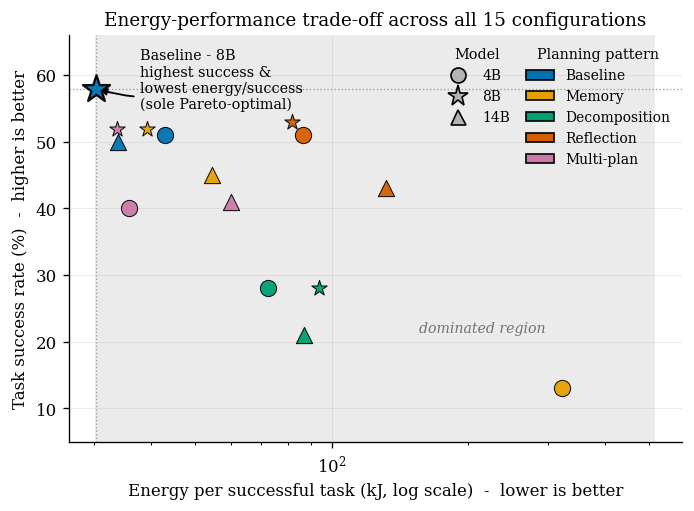

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 4.4))
T = table1.reset_index()
best = T.loc[(T["Succ%"].rank(ascending=False) + T["EperSucc_kJ"].rank()).idxmin()]

ax.axvspan(best["EperSucc_kJ"], T["EperSucc_kJ"].max()*1.6, color="0.92", zorder=0)
ax.axhline(best["Succ%"], color="0.6", lw=0.8, ls=":", zorder=1)
ax.axvline(best["EperSucc_kJ"], color="0.6", lw=0.8, ls=":", zorder=1)
ax.text(T["EperSucc_kJ"].max()*0.92, 22, "dominated region",
        color="0.45", ha="right", va="center", fontsize=8.5, style="italic")

for _, r in T.iterrows():
    is_best = (r["pattern"]==best["pattern"]) and (r["model"]==best["model"])
    ax.scatter(r["EperSucc_kJ"], r["Succ%"],
               s=290 if is_best else 95, marker=MODEL_MARKER[r["model"]],
               facecolor=PATTERN_COLOR[r["pattern"]], edgecolor="black",
               linewidth=1.4 if is_best else 0.6, zorder=5, alpha=0.95)

ax.annotate("Baseline - 8B\nhighest success &\nlowest energy/success\n(sole Pareto-optimal)",
            xy=(best["EperSucc_kJ"], best["Succ%"]),
            xytext=(best["EperSucc_kJ"]*1.25, 64), fontsize=8.6, ha="left", va="top",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.1,
                            connectionstyle="arc3,rad=-0.2"))
ax.set_xscale("log")
ax.set_xlabel("Energy per successful task (kJ, log scale)  -  lower is better")
ax.set_ylabel("Task success rate (%)  -  higher is better")
ax.set_title("Energy-performance trade-off across all 15 configurations")
ax.set_ylim(5, 66)
pat_h = [Patch(facecolor=PATTERN_COLOR[p], edgecolor="black", label=PATTERN_LABEL[p]) for p in PATTERN_ORDER]
mod_h = [Line2D([0],[0], marker=MODEL_MARKER[m], color="0.3", linestyle="",
                markersize=13 if m=="qwen3:8b" else 9, markerfacecolor="0.7",
                markeredgecolor="black", label=MODEL_LABEL[m]) for m in MODEL_ORDER]
leg1 = ax.legend(handles=pat_h, title="Planning pattern", loc="upper right",
                 bbox_to_anchor=(1.0,1.0), fontsize=8.3, title_fontsize=8.6)
ax.add_artist(leg1)
ax.legend(handles=mod_h, title="Model", loc="upper right",
          bbox_to_anchor=(0.74,1.0), fontsize=8.3, title_fontsize=8.6)
save(fig, "fig1_pareto"); plt.show()

### Figure 4 — Main effects: success and energy-per-success by pattern × model

wrote figures/fig2_main_effects.pdf and .png


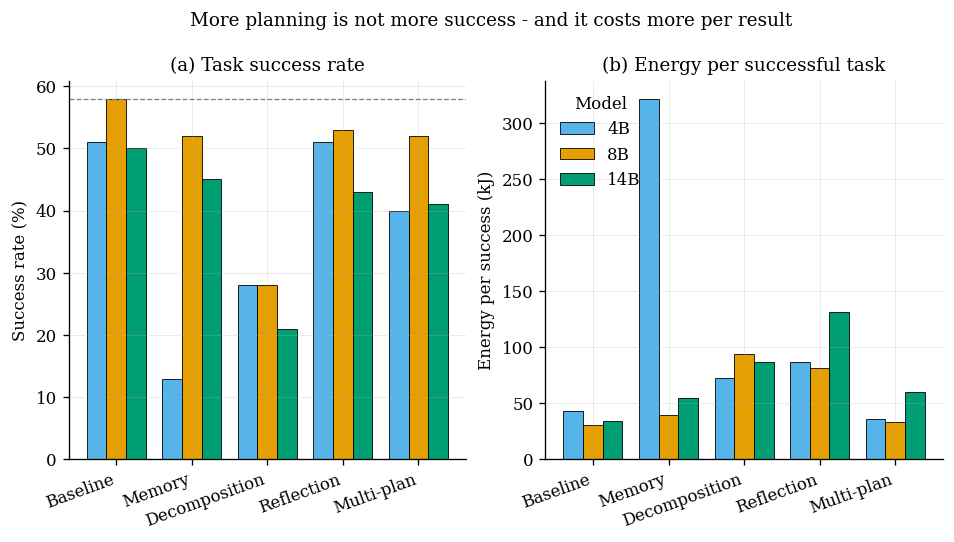

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.1))
x = np.arange(len(PATTERN_ORDER)); w = 0.26
for ax, col, title, ylab in [
    (axes[0], "Succ%",       "(a) Task success rate",          "Success rate (%)"),
    (axes[1], "EperSucc_kJ", "(b) Energy per successful task", "Energy per success (kJ)")]:
    for i, m in enumerate(MODEL_ORDER):
        vals = [cell(p, m, col) for p in PATTERN_ORDER]
        ax.bar(x + (i-1)*w, vals, w, label=MODEL_LABEL[m],
               color=MODEL_COLOR[m], edgecolor="black", linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels([PATTERN_LABEL[p] for p in PATTERN_ORDER],
                                         rotation=20, ha="right")
    ax.set_title(title); ax.set_ylabel(ylab)
axes[0].axhline(cell("baseline","qwen3:8b","Succ%"), color="0.5", lw=0.8, ls="--")
axes[1].legend(title="Model", loc="upper left")
fig.suptitle("More planning is not more success - and it costs more per result", fontsize=11, y=1.02)
save(fig, "fig2_main_effects"); plt.show()

### Figure 5 — Reliability as a sustainability axis (no-output rates + the Memory–4B reversal)

wrote figures/fig3_reliability.pdf and .png


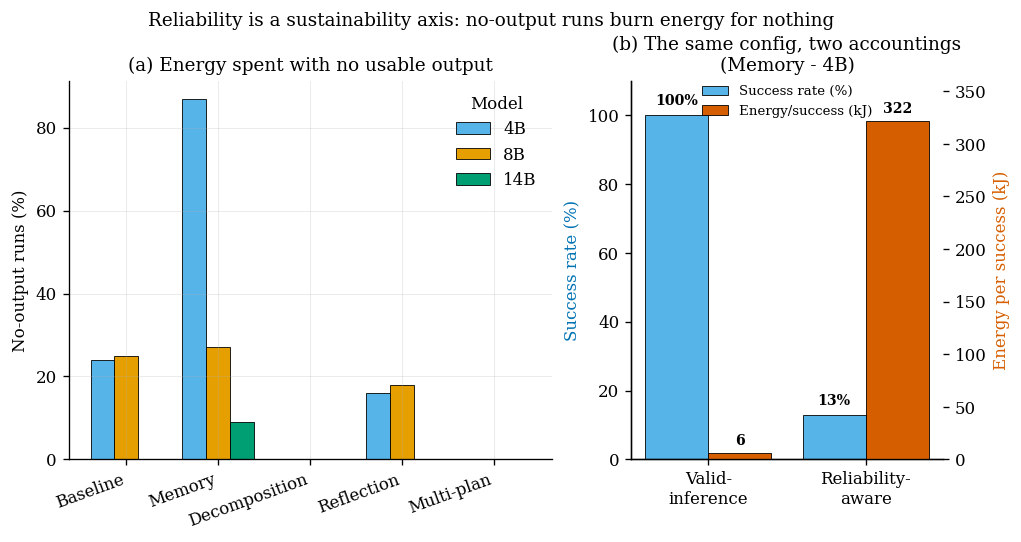

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.1), gridspec_kw={"width_ratios":[1.55,1]})

# (a) no-output rate by pattern x model
ax = axes[0]
for i, m in enumerate(MODEL_ORDER):
    vals = [cell(p, m, "NoOut%") for p in PATTERN_ORDER]
    ax.bar(x + (i-1)*w, vals, w, label=MODEL_LABEL[m],
           color=MODEL_COLOR[m], edgecolor="black", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels([PATTERN_LABEL[p] for p in PATTERN_ORDER], rotation=20, ha="right")
ax.set_ylabel("No-output runs (%)"); ax.set_title("(a) Energy spent with no usable output")
ax.legend(title="Model", loc="upper right")

# (b) the Memory-4B accounting reversal (dual axis)
ax = axes[1]; ax2 = ax.twinx()
xb = np.arange(2)
b1 = ax.bar(xb-0.2, [succ_valid, succ_ra], 0.4, color="#56B4E9", edgecolor="black",
            linewidth=0.5, label="Success rate (%)")
b2 = ax2.bar(xb+0.2, [eps_valid, eps_ra], 0.4, color="#D55E00", edgecolor="black",
             linewidth=0.5, label="Energy/success (kJ)")
ax.set_xticks(xb); ax.set_xticklabels(["Valid-\ninference","Reliability-\naware"])
ax.set_ylabel("Success rate (%)", color="#0072B2"); ax2.set_ylabel("Energy per success (kJ)", color="#D55E00")
ax.set_ylim(0,110); ax2.set_ylim(0,360)
ax.set_title("(b) The same config, two accountings\n(Memory - 4B)")
for xx, v in zip(xb-0.2, [succ_valid, succ_ra]): ax.text(xx, v+3, f"{v:.0f}%", ha="center", fontsize=8.5, weight="bold")
for xx, v in zip(xb+0.2, [eps_valid, eps_ra]):  ax2.text(xx, v+8, f"{v:.0f}", ha="center", fontsize=8.5, weight="bold")
ax.grid(False); ax2.grid(False)
ax.legend([b1,b2], [b1.get_label(), b2.get_label()], loc="upper center",
          bbox_to_anchor=(0.5,1.02), fontsize=8.0)
fig.suptitle("Reliability is a sustainability axis: no-output runs burn energy for nothing", fontsize=11, y=1.02)
save(fig, "fig3_reliability"); plt.show()

<h3 style="background-color:blue; color: white; padding: 15px;"> 10. Summary of reproduced headline numbers </h3>

In [17]:
print("Headline numbers reproduced from run_table.csv")
print("-"*60)
print(f"Total runs analysed                 : {len(df)}")
print(f"Pareto-optimal config               : Baseline · 8B")
print(f"  success (reliability-aware)        : {cell('baseline','qwen3:8b','Succ%'):.0f}%")
print(f"  energy per success                 : {cell('baseline','qwen3:8b','EperSucc_kJ'):.1f} kJ")
print(f"Marginal success: 8B {df[df.model=='qwen3:8b'].success.mean()*100:.1f}% "
      f"> 14B {df[df.model=='qwen3:14b'].success.mean()*100:.1f}% "
      f"> 4B {df[df.model=='qwen3:4b'].success.mean()*100:.1f}%")
print(f"Memory-4B reversal: valid {succ_valid:.0f}%/{eps_valid:.1f}kJ "
      f"-> reliability-aware {succ_ra:.0f}%/{eps_ra:.1f}kJ")

Headline numbers reproduced from run_table.csv
------------------------------------------------------------
Total runs analysed                 : 1500
Pareto-optimal config               : Baseline · 8B
  success (reliability-aware)        : 58%
  energy per success                 : 30.4 kJ
Marginal success: 8B 48.6% > 14B 40.0% > 4B 36.6%
Memory-4B reversal: valid 100%/5.7kJ -> reliability-aware 13%/321.5kJ
